# Calibrate the Hydrologic Model

Up to now the hydrologic model has been run with its factory-default
parameters, which rarely match a real catchment. **Calibration** is the process
of adjusting those parameters so the simulated streamflow matches the
observations. A real model has a handful of storage and threshold
coefficients that we can tune - the melting threshold, the surface field
capacity, the groundwater recession constants, and so on.

This notebook uses the calibration method that ships with `potions`:
`HydrologicalModel.simple_calibration`. It runs a global optimizer (differential
evolution) over the model's parameter space, repeatedly running the model and
scoring each parameter set by how well its streamflow fits the observations
(measured by Nash-Sutcliffe efficiency here), and returns the best parameters
it found.

The steps are:

1. Load the input data
2. Run the model with its default parameters and score it
3. Look at the parameters we are free to tune (and their allowed ranges)
4. Run `simple_calibration` to find better parameters
5. Compare the before and after (parameters and fit)
6. Plot the simulated vs. observed streamflow, before and after calibration

This is a Jupytext-style percent script: code cells are delimited by `# %%`
and text cells by `# %% [markdown]`.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from pandas import DataFrame, Series

import potions as pt

# The notebooks in this repo are expected to be run from the `scripts` directory,
# so the data lives one level up, in `../data`.
data_dir: str = "../data"
forcing_path: str = os.path.join(data_dir, "model_inputs", "forcing.csv")
measured_path: str = os.path.join(data_dir, "model_inputs", "measured_data.csv")

## 1. Load the input data

The two files written out by the first notebook: the daily weather drivers and
the observations. For a hydrologic calibration we need the driving series
(`ppt`, `temp`, `pet`) and the observed streamflow (`q_mmd`) to score the
simulation against.

In [2]:
forcing_df: DataFrame = pd.read_csv(forcing_path, index_col=0, parse_dates=True)
measured_df: DataFrame = pd.read_csv(measured_path, index_col=0, parse_dates=True)

# Bundle the three weather series into a single forcing data object, and keep the
# observed streamflow handy for scoring.
forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"],
    temp=forcing_df["temp"],
    pet=forcing_df["pet"],
)
meas_streamflow: Series = measured_df["q_mmd"]

print(
    f"Forcing spans {forcing_df.index[0].date()} to {forcing_df.index[-1].date()} ({len(forcing_df)} days)"
)
print(
    f"Measured streamflow spans {meas_streamflow.index[0].date()} to {meas_streamflow.index[-1].date()} ({len(meas_streamflow)} days)"
)

Forcing spans 2008-10-01 to 2015-09-30 (2554 days)
Measured streamflow spans 2009-10-01 to 2015-09-30 (2191 days)


## 2. Run the model with its default parameters

First we get a baseline: run the model with the parameters that come out of the
box (no tuning) and note how well - or poorly - its streamflow matches the
observations. We use the usual four-zone `HbvModel` with everything at default.

In [3]:
# A model with all-default parameters.
baseline_model: pt.HbvModel = pt.HbvModel()

baseline_results: pt.HydroModelResults = baseline_model.run_hydro_model(
    forc=forcing,
    meas_streamflow=meas_streamflow,
)

print("Default (untuned) performance metrics:")
print(baseline_results.objective_functions)

Default (untuned) performance metrics:
kge             0.106067
log_kge        -0.111362
nse             0.137618
log_nse        -0.113385
bias            0.257206
spearman_rho    0.569859
r_squared       0.160143
dtype: float64


## 3. Look at the parameters we can tune

`simple_calibration` needs to know *which* parameters to vary and *how much*
room each one has. `HydrologicalModel.default_parameter_ranges()` gives exactly
that: for every tunable parameter, a `(minimum, maximum)` allowed range. These
ranges are read from the zone classes (each zone knows its own parameters and a
sensible search window).

There is one convention worth flagging: the recession constants of the
groundwater stores (`shallow.k`, `deep.k`) are searched on a **log scale**, so
their bounds are *negative* (e.g. `(-5, -1)`). A negative value means
"log10(k)"; the optimizer explores `log10(k)`, and the natural (positive)
value is recovered as `k = 10 ** (log10(k))`. All the other parameters are on
their natural (positive) scale, with positive bounds.

In [4]:
# The tunable parameters and their allowed ranges, straight from the model class.
param_ranges: dict[str, tuple[float, float]] = pt.HbvModel.default_parameter_ranges()

print(f"Number of tunable parameters: {len(param_ranges)}")
print()
for name, (lo, hi) in param_ranges.items():
    scale: str = "log10 (negative bounds)" if lo < 0 else "natural scale"
    print(f"   {name:<16} in [{lo:>9.4g}, {hi:>9.4g}]   ({scale})")

Number of tunable parameters: 12

   snow.tt          in [       -1,         1]   (log10 (negative bounds))
   snow.fmax        in [      0.5,         5]   (natural scale)
   surface.fc       in [       50,      1000]   (natural scale)
   surface.lp       in [     0.05,         1]   (natural scale)
   surface.beta     in [     0.05,         5]   (natural scale)
   surface.k0       in [        0,         1]   (natural scale)
   surface.thr      in [        0,      1000]   (natural scale)
   shallow.k        in [       -5,        -1]   (log10 (negative bounds))
   shallow.alpha    in [      0.5,         3]   (natural scale)
   shallow.perc     in [        0,         5]   (natural scale)
   deep.k           in [       -5,        -1]   (log10 (negative bounds))
   deep.alpha       in [      0.5,         3]   (natural scale)


## 4. Run the calibration

We call `simple_calibration` as a class method on the model. It:

1. Starts from the parameter ranges we looked at above (we let it use the
   defaults by not passing `param_ranges`).
2. Uses **differential evolution**, a global, population-based optimizer, to
   search the space (so we do not need to supply a starting guess).
3. Scores every candidate by the objective we choose with `metric`. We use
   `"nse"` (Nash-Sutcliffe efficiency of the streamflow).
4. Returns three things: the best parameter **dictionary**, a full model
   **results** object for the best fit, and the raw SciPy `OptimizeResult`.

We deliberately keep this a *demonstration* by capping `maxiter` (the number of
optimizer generations) at 5 and using a few worker threads. A fuller
calibration would run many more generations (and could take minutes); bump
`maxiter` up to get a tighter fit.

In [5]:
# Run the built-in calibration. `maxiter=5` keeps this quick; raise it for a
# more thorough calibration.
cal_params, cal_results, cal_optimize_result = pt.HbvModel.simple_calibration(
    forc=forcing,
    meas_streamflow=meas_streamflow,
    metric="nse",
    maxiter=5,
    num_threads=8,
    polish=True,
)

print("Calibration complete.")
print(f"Function evaluations: {cal_optimize_result.nfev}")
print(f"Optimizer converged?  {bool(cal_optimize_result.success)}")
print()
print("Calibrated model performance metrics:")
print(cal_results.objective_functions)

Calibration complete.
Function evaluations: 1951
Optimizer converged?  False

Calibrated model performance metrics:
kge             0.657502
log_kge         0.382349
nse             0.540554
log_nse         0.372723
bias           -0.122787
spearman_rho    0.703903
r_squared       0.558836
dtype: float64


## 5. Compare before and after

`simple_calibration` returns the best parameters in a dictionary keyed as
`<zone>.<parameter>` - the same keys the model uses in `to_dict()`. But there is
a twist: the groundwater recession constants `shallow.k` and `deep.k` come back
on the **log scale** (negative), because that is how the optimizer searches them.
The model's own `to_dict()` reports those same parameters on the **natural**
(positive) scale. To put the two side by side cleanly, we rebuild the model from
the calibrated parameters and read its parameters back with `to_dict()`, which
normalises everything - including converting `k` back to its natural value - so
the "before" and "after" columns are directly comparable.

In [8]:
# The calibrated parameters exactly as the optimizer returned them. Note that the
# groundwater recession constants shallow.k and deep.k are negative here: they are
# in log scale (log10(k)), so the natural value is k = 10 ** (that number).
param_order: list[str] = list(cal_params.keys())

print("Calibrated parameters, as returned (note shallow.k / deep.k are negative):")
for name in param_order:
    print(f"   {name:<16} {cal_params[name]:>12.5g}")
print()

# Rebuild the model from the calibrated parameters and read back the *natural*
# values so we can compare against the defaults on the same scale.
# `hydro_from_array` expects the parameters in the model's order; because the
# groundwater k values are stored in log10 scale, handing them straight back in
# that same scale reconstructs the model correctly, and `to_dict()` then reports
# everything (including k) on the natural scale.
calibrated_model: pt.HbvModel = pt.HbvModel.hydro_from_array(
    np.array([cal_params[name] for name in param_order], dtype=np.float64)
)
default_values: dict[str, float] = baseline_model.to_dict()
calibrated_values: dict[str, float] = calibrated_model.to_dict()

# A tidy before/after table. We show the natural (positive) values for every
# parameter, which is the physically meaningful scale.
comparison: DataFrame = pd.DataFrame(
    {
        "parameter": list(default_values.keys()),
        "default": np.array(
            [default_values[k] for k in default_values.keys()], dtype=np.float64
        ),
        "calibrated": np.array(
            [calibrated_values[k] for k in default_values.keys()], dtype=np.float64
        ),
    }
).set_index("parameter")
print("Parameters on the natural scale (default -> calibrated):")
print(comparison.to_string(float_format=lambda v: f"{v:.5g}"))
print()

# The headline: how much did the fit improve?
default_nse: float = float(baseline_results.objective_functions["nse"])
cal_nse: float = float(cal_results.objective_functions["nse"])
default_kge: float = float(baseline_results.objective_functions["kge"])
cal_kge: float = float(cal_results.objective_functions["kge"])
print(f"NSE:  {default_nse:.4f} (default)  ->  {cal_nse:.4f} (calibrated)")
print(f"KGE:  {default_kge:.4f} (default)  ->  {cal_kge:.4f} (calibrated)")

Calibrated parameters, as returned (note shallow.k / deep.k are negative):
   snow.tt              -0.39079
   snow.fmax              4.5292
   surface.fc              345.9
   surface.lp            0.61219
   surface.beta           1.3003
   surface.k0            0.19152
   surface.thr            835.54
   shallow.k             -2.5663
   shallow.alpha          2.3984
   shallow.perc           0.5565
   deep.k                -3.9618
   deep.alpha             1.4262

Parameters on the natural scale (default -> calibrated):
               default  calibrated
parameter                         
snow.tt              0    -0.39079
snow.fmax            1      4.5292
surface.fc         100       345.9
surface.lp         0.5     0.61219
surface.beta         1      1.3003
surface.k0         0.1     0.19152
surface.thr         10      835.54
shallow.k         0.01   0.0027147
shallow.alpha        1      2.3984
shallow.perc         1      0.5565
deep.k            0.01  0.00010918
deep.alpha      

## 6. Plot the simulated vs. observed streamflow, before and after

The payoff of calibration is visual: the untuned model (gray) sits roughly at
the "right" order of magnitude but misses the timing and size of the floods,
while the calibrated model (blue) tracks the observed hydrograph much more
closely. We overlay both on the daily drivers (precipitation as light bars,
temperature as a thin line), as in the earlier notebooks.

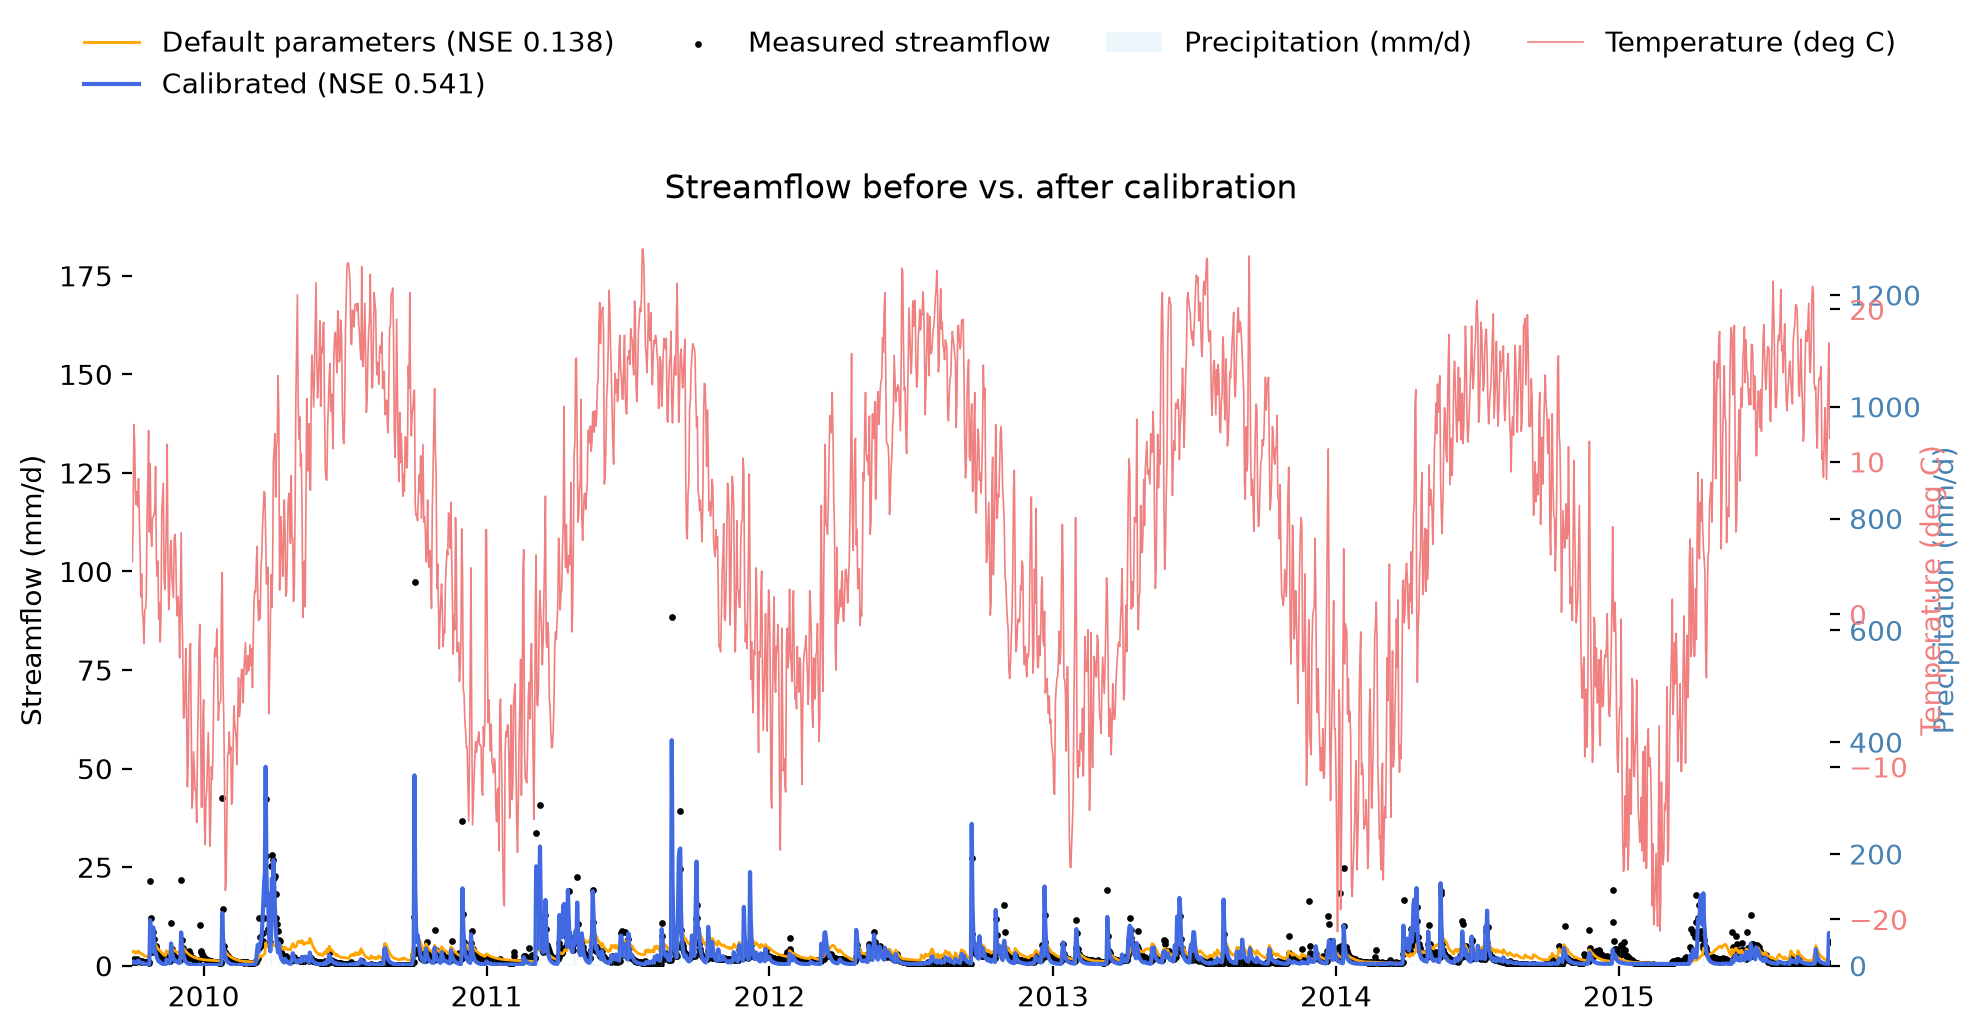


Calibration improved streamflow NSE from 0.1376 (default) to 0.5406 (calibrated); KGE from 0.1061 to 0.6575.
To improve the fit further, increase `maxiter` in the `simple_calibration` call above.


In [9]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["legend.frameon"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False

obs_start: pd.Timestamp = meas_streamflow.index[0]
obs_end: pd.Timestamp = meas_streamflow.index[-1]

baseline_sim: DataFrame = baseline_results.simulation
calibrated_sim: DataFrame = cal_results.simulation

fig: Figure = plt.figure(figsize=(10, 4.5))
ax: Axes = fig.gca()

# Daily drivers for context, on secondary axes.
ax_ppt: Axes = ax.twinx()
ax_ppt.bar(
    forcing_df.index,
    forcing_df["ppt"],
    width=1.0,
    alpha=0.15,
    color="skyblue",
    label="Precipitation (mm/d)",
)
ax_ppt.set_ylabel("Precipitation (mm/d)", color="steelblue")
ax_ppt.tick_params(axis="y", labelcolor="steelblue")
ax_ppt.set_ylim(0, forcing_df["ppt"].max() * 8)

ax_temp: Axes = ax.twinx()
ax_temp.plot(
    forcing_df.index,
    forcing_df["temp"],
    color="lightcoral",
    linewidth=0.6,
    label="Temperature (deg C)",
)
ax_temp.set_ylabel("Temperature (deg C)", color="lightcoral")
ax_temp.tick_params(axis="y", labelcolor="lightcoral")

# The three streamflows on the primary axis.
ax.plot(
    baseline_sim.index,
    baseline_sim["streamflow_sim"],
    color="orange",
    linewidth=1.0,
    label=f"Default parameters (NSE {default_nse:.3f})",
)
ax.plot(
    calibrated_sim.index,
    calibrated_sim["streamflow_sim"],
    color="royalblue",
    label=f"Calibrated (NSE {cal_nse:.3f})",
)
ax.scatter(
    meas_streamflow.index,
    meas_streamflow,
    s=2,
    color="black",
    label="Measured streamflow",
)

ax.set_xlim(obs_start, obs_end)
max_q: float = max(
    baseline_sim["streamflow_sim"].quantile(0.99),
    calibrated_sim["streamflow_sim"].quantile(0.99),
)
ax.set_ylim(0, max_q * 10)
ax.set_ylabel("Streamflow (mm/d)")
ax.set_title("Streamflow before vs. after calibration")
fig.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=4)
fig.tight_layout()
plt.show()

# A short closing note in the console so the result is summarised in the log too.
print()
print(
    f"Calibration improved streamflow NSE from {default_nse:.4f} (default) to {cal_nse:.4f} "
    f"(calibrated); KGE from {default_kge:.4f} to {cal_kge:.4f}."
)
print(
    "To improve the fit further, increase `maxiter` in the `simple_calibration` call above."
)